In [1]:
# 导入所需要的包
import collections
import math
import os
import shutil
import pandas as pd
import torch
import torchvision
from torch import nn
from d2l import torch as d2l

In [2]:
# 设置数据集路径
data_dir = '../data/cifar-10/'

In [3]:
# 读取csv文件

# 读取fname来给标签字典返回一个文件名
# fname是函数的传入参数，代表传入的csv文件地址
def read_csv_labels(fname):

    with open(fname, 'r') as f:
    # 使用with语句打开文件，确保文件在操作完毕后自动关闭
    # 'r'表示以只读模式打开文件
    # f 是文件对象，用于后续读取文件内容
        
        # 跳过文件第一行
        lines = f.readlines()[1:]
        # f.readlines读取文件所有行，返回一个列表。每行是一个字符串
        # [1:]切片操作，跳过文件第一行，只保留从第二行开始的内容

    # 处理每行数据并分割
    tokens = [l.rstrip().split(',') for l in lines]
    # l.rstrip()去除每行末尾的空格（包括换行符）
    # l.split(';')将每一行按“；”分割成多个字段
    # [... for l in lines] 表示对lines中每一行l执行相应的操作，并返回一个新的列表tokens

    # 创建并返回字典
    return dict(((name, label) for name, label in tokens))
    # dict() 将列表或其他可迭代对象转换为字典
    # ((name, label) for name, label in tokens)：通过生成器表达式遍历 tokens 列表，
    #           将每个 tokens 中的元素拆分成 name 和 label，并将它们作为字典的键值对。
    # 例如，tokens 列表中的每个元素是一个列表 [name, label]，该表达式将其转换为字典中的条目 name: label。

# 函数调用与输出
labels = read_csv_labels(os.path.join(data_dir, 'trainLabels.csv'))
# os.path.join(data_dir, 'trainLabels.csv')：使用 os.path.join 拼接文件路径，保证跨平台兼容性
# （例如，Windows 和 Linux 路径分隔符不同）。

# 打印结果
print('# 训练样本：', len(labels))
print('# 类别：', len(set(labels.values())))
# len(labels)获取字典labels中键值对的数量，即训练样本数。
# labels.values():获取字典中所有值的列表（即标签）
# set(labels.values()):将标签列表转换为集合，自动去除重复项，因此计算不同标签的数量

# 训练样本： 50000
# 类别： 10


In [4]:
# 提取验证集

# 将文件复制到目录
def copyfile(filename, target_dir):

    # 确保目录存在，没有就创建
    os.makedirs(target_dir, exist_ok = True)

    # 将指定文件filename复制到目标目录
    shutil.copy(filename, target_dir)

# 将验证集从原始的训练集中拆分出来
def reorg_train_valid(data_dir, labels, valid_ratio):
    # valid_ratio验证集所占数据集的比例

    # 得到训练数据集中样本最少的类别中样本数n
    n = collections.Counter(labels.values()).most_common()[-1][1]
    # collections.Counter(labels.values())统计每一个标签类别的样本数量
    #     labels.values() 返回的是一个包含所有标签的列表
    #    （例如，['cat', 'dog', 'cat', 'cat', 'dog']）。Counter 用于统计每个标签的出现频率。
    #     结果可能是Counter({'cat': 3, 'dog': 2})
    # most_common():这是counter对象的方法，用于返回一个按频率排序的元组列表。
    # 每个元组第一个元素是标签，第二个元素是标签的出现次数。调用 most_common() 返回的结果是按频率从高到低排序的：
    # [('cat', 3), ('dog', 2)]
    # [-1] 表示取出 most_common() 返回列表中的最后一个元素
    # [1] 表示获取第二个元素，即出现频率，赋值给n

    # 计算验证集中每个类别的样本数
    n_valid_per_label = max(1, math.floor(n * valid_ratio))
    # 通过 math.floor(n * valid_ratio) 来取出每个类别应该分配到验证集的样本数量，max(1, ...) 确保至少有 1 个验证样本。

    # 初始化标签计数字典
    label_count = {}
    # label_count 是一个字典，用于存储每个类别已经分配到验证集的样本数量。
    # 例如，label_count = {'cat': 1, 'dog': 0} 表示
    #      'cat' 类别已经有 1 个样本被分配到验证集，'dog' 类别没有样本被分配到验证集。

    # 遍历训练集中的文件，按照标签分配到训练集或验证集
    for train_file in os.listdir(os.path.join(data_dir,'train')):
    # os.listdir(os.path.join(data_dir,'train')) 遍历训练集目录中所有样本
        label = labels[train_file.split('.')[0]]
        # train_file.split('.')[0]：
        # 假设文件名格式为 id.png，split('.')[0] 会提取出文件名的id部分（例如：1.png 中的 1）。
        # labels[train_file.split('.')[0]]通过文件名的id部分从labels字典中获取真实的标签
        
        fname = os.path.join(data_dir, 'train', train_file)
        # 获取训练集文件的完整路径
        
        copyfile(fname, os.path.join(data_dir, 'train_valid_test', 'train_valid', label))
        # 将文件复制到新的训练集路径 train_valid_test/train/label 中。文件按照标签被复制到对应的文件夹中。

        if label not in label_count or label_count[label] < n_valid_per_label:
        # 检查当前标签是否已经分配到足够的验证集样本，不够就分配到验证集
            copyfile(fname, os.path.join(data_dir, 'train_valid_test', 'valid', label))
            # 将文件复制到验证集文件夹中
            label_count[label] = label_count.get(label, 0) + 1
            # 更新该标签验证集样本数量
        else:
        # 如果该类别已经有足够的验证集样本，就将文件分配给训练集
            copyfile(fname, os.path.join(data_dir, 'train_valid_test', 'train', label))
            # 将文件复制到训练集文件夹中
    return n_valid_per_label
    # 返回每个标签验证集样本数量

In [5]:
# 在预测期间整理测试集，以方便读取
# 这个函数的目的是在测试期间整理测试集文件，并将它们复制到指定的目标路径。
def reorg_test(data_dir):
    for test_file in os.listdir(os.path.join(data_dir, 'test')):
        copyfile(os.path.join(data_dir, 'test', test_file), 
                 os.path.join(data_dir, 'train_valid_test', 'test', 'unknown'))
        # 复制到目录是一个"未知类别"文件夹

In [6]:
# 最后定义一个函数调用之前的readread_csv_labels,reoreorg_train_valid和reorreorg_test
def reorg_cifar10_data(data_dir, valid_ratio):
    labels = read_csv_labels(os.path.join(data_dir, 'trainLabels.csv'))
    reorg_train_valid(data_dir, labels, valid_ratio)
    reorg_test(data_dir)

In [7]:
# 设置参数并调用刚刚定义的数据读取函数

batch_size = 128
valid_ratio = 0.1
reorg_cifar10_data(data_dir, valid_ratio)

In [8]:
# 训练期间的图像增广

transform_train = torchvision.transforms.Compose([
    # 在高度和宽度上将图像放大到40像素的正方形
    torchvision.transforms.Resize(40),
    # 随机裁剪出一个高度和宽度均为40像素的正方形图像，
    # 生成一个面积为原始图像面积0.64~1倍的小正方形，
    # 然后将其缩放为高度和宽度均为32像素的正方形
    torchvision.transforms.RandomResizedCrop(32, scale = (0.64, 1.0),
                                             ratio = (1.0, 1.0)),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor(),
    # 标准化图像的每个通道
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465],
                                     [0.2023, 0.1994, 0.2010])
])

In [9]:
# 测试期间的图像增广

transform_test = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465],
                                     [0.2023, 0.1994, 0.2010])
])

In [10]:
# 读取原始图像组成的数据集，每个样本包含一张照片和一个标签
# ImageFolder(root, transform=None, target_transform=None, loader=...) 是一个 Dataset：
# 目录约定：root 下每个子文件夹名就是一个类别；子文件夹里放该类的所有图片。

# 这四个对象是 torchvision.datasets.ImageFolder 类的实例（也就是四个 Dataset 对象）
train_ds, train_valid_ds = [torchvision.datasets.ImageFolder(
    os.path.join(data_dir, 'train_valid_test', folder),
    transform = transform_train) for folder in ['train', 'train_valid']]
# 把列表的两个元素分别赋值给 train_ds 和 train_valid_ds

valid_ds, test_ds = [torchvision.datasets.ImageFolder(
    os.path.join(data_dir, 'train_valid_test', folder),
    transform = transform_test) for folder in ['valid', 'test']]

In [11]:
# 指定上面定义的所有图像的增广操作
train_iter, train_valid_iter = [torch.utils.data.DataLoader(
    dataset, batch_size, shuffle=True, drop_last=True)
    for dataset in (train_ds, train_valid_ds)]

valid_iter = torch.utils.data.DataLoader(valid_ds, batch_size, shuffle=False, drop_last=True)

test_iter = torch.utils.data.DataLoader(test_ds, batch_size, shuffle=False, drop_last=False)

In [12]:
# 定义模型Resnet-18

def get_net():
    num_classes = 10
    net = d2l.resnet18(num_classes, 3)
    return net

loss = nn.CrossEntropyLoss(reduction='none')

In [13]:
# 定义训练函数
def train(net, train_iter, valid_iter, num_epochs, lr, wd, devices, lr_period, lr_decay):
    trainer = torch.optim.SGD(net.parameters(), lr=lr, momentum=0.9, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.StepLR(trainer, lr_period, lr_decay)
    num_batches, timer = len(train_iter), d2l.Timer()
    legend = ['train loss', 'train acc']
    if valid_iter is not None:
        legend.append('valid acc')
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs], legend=legend)
    net = nn.DataParallel(net, device_ids=devices).to(devices[0])
    for epoch in range(num_epochs):
        net.train()
        metric = d2l.Accumulator(3)
        for i, (features, labels) in enumerate(train_iter):
            timer.start()
            l, acc = d2l.train_batch_ch13(net, features, labels,
                                          loss, trainer, devices)
            metric.add(l, acc, labels.shape[0])
            timer.stop()
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (metric[0] / metric[2], metric[1] / metric[2], None))
        if valid_iter is not None:
            valid_acc = d2l.evaluate_accuracy_gpu(net, valid_iter)
            animator.add(epoch + 1, (None, None, valid_acc))
        scheduler.step()
    measures = (f'train loss {metric[0] / metric[2]:.3f},'
                f'train acc {metric[1] / metric[2]:.3f}')
    if valid_iter is not None:
        measures += f', valid acc {valid_acc:.3f}'
    print(measures + f'\n{metric[2] * num_epochs / timer.sum():.1f}'
        f' examples/sec on {str(devices)}')

train loss 0.155,train acc 0.945, valid acc 0.857
930.8 examples/sec on [device(type='cuda', index=0), device(type='cuda', index=1), device(type='cuda', index=2), device(type='cuda', index=3)]


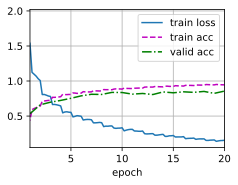

In [14]:
 # 训练和验证模型
devices, num_epochs, lr, wd = d2l.try_all_gpus(), 20, 2e-4, 5e-4
lr_period, lr_decay, net = 4, 0.9, get_net()
train(net, train_iter, valid_iter, num_epochs, lr, wd, devices, lr_period, lr_decay)

train loss 0.145,train acc 0.950
935.7 examples/sec on [device(type='cuda', index=0), device(type='cuda', index=1), device(type='cuda', index=2), device(type='cuda', index=3)]


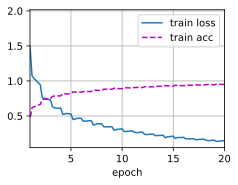

In [15]:
# 对训练集和验证集重新训练模型

net, preds = get_net(), []
train(net, train_valid_iter, None, num_epochs, lr, wd, devices, lr_period, lr_decay)

In [19]:
for X, _ in test_iter:
    y_hat = net(X.to(devices[0]))
    preds.extends(y_hat.argmax(dim=1),type(torch.int32).cpu().numpy())
sorted_ids = list(range(1, len(test_ds) + 1))
sorted_ids.sort(key=lambda x: str(x))
df = pd.DataFrame({'id':sorted_ids, 'labels':preds})
df['label'] = df['label'].apply(lambda x: train_valid_ds.classes[x])
df.to_csv('submission.csv', index=False)

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:1 and cuda:0! (when checking argument for argument weight in method wrapper_CUDA__cudnn_convolution)